# Shapley Values

In [ ]:
# !pip install shap==0.40.0

In [ ]:
#!pip install xgboost

In [1]:
# Import the SHAP library - https://github.com/slundberg/shap
import shap
import xgboost
import tensorflow as tf

import sklearn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Imports necessários
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # para particionar em bases de treino e teste (holdout)
from sklearn.model_selection import KFold # para preparar os folds da validação cruzada
from sklearn.model_selection import cross_val_score # para executar a validação cruzada
from sklearn.metrics import accuracy_score # para a exibição da acurácia do modelo
from sklearn.linear_model import LogisticRegression # algoritmo Regressão Logística
from sklearn.neighbors import KNeighborsClassifier # algoritmo KNN
from sklearn.tree import DecisionTreeClassifier # algoritmo Árvore de Classificação
from sklearn.naive_bayes import GaussianNB # algoritmo Naive Bayes
from sklearn.svm import SVC # algoritmo SVM
from sklearn.preprocessing import MinMaxScaler

#Regressão
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

2024-08-30 11:42:51.016173: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-08-30 11:42:51.016204: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
print(f'The scikit-learn version is {sklearn.__version__}.')  # 1.0.1
print(f'The tensorflow version is {tf.__version__}.')  # 2.4.0
print(f'The shap version is {shap.__version__}.')  # 0.40.0
print(f'The xgboost version is {xgboost.__version__}.')  # 1.5.0

The scikit-learn version is 1.0.2.
The tensorflow version is 2.4.0.
The shap version is 0.40.0.
The xgboost version is 1.6.2.


### Leitura dos dados

In [3]:
df = pd.read_csv('/home/rogerio/Downloads/INEP/2021/DADOS_ED_PROCESSADOS_REGRESSAO.csv', encoding="latin-1", sep = ';')
df

,TX_APR,TX_REP,TX_ABD,TNR,TDI,IRD,IED_NIVEL1,IED_NIVEL2,IED_NIVEL3,IED_NIVEL4,...,QT_TUR_INF,QT_TUR_PROF,QT_TUR_PROF_TEC,QT_TUR_EJA,QT_TUR_EJA_FUND,QT_TUR_EJA_MED,QT_TUR_ESP,QT_TUR_ESP_CC,QT_TUR_ESP_CE,VL_OBSERVADO_2021
0,100.0,0.0,0.0,2.0,4.0,2.8,33.4,33.3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,0.0,5.9
1,100.0,0.0,0.0,9.5,0.0,2.7,75.0,0.0,0.0,25.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,4.1
2,67.5,32.5,0.0,7.0,4.5,3.2,50.0,0.0,0.0,50.0,...,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,2.7
3,96.9,3.1,0.0,1.5,4.5,3.4,50.0,0.0,0.0,50.0,...,1.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,4.1
4,78.9,21.1,0.0,17.4,60.0,3.0,50.0,0.0,0.0,50.0,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,7.0,0.0,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54271,94.7,5.3,0.0,4.5,32.4,2.4,0.0,2.2,76.6,8.5,...,0.0,0.0,0.0,16.0,10.0,6.0,33.0,33.0,0.0,4.4
54272,93.9,4.1,2.0,2.8,37.0,2.5,0.0,0.0,80.5,14.6,...,0.0,0.0,0.0,10.0,0.0,10.0,35.0,35.0,0.0,5.2
54273,98.4,1.6,0.0,4.8,17.5,1.7,0.0,0.0,85.7,14.3,...,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.0,0.0,5.2
54274,96.2,3.8,0.0,3.0,23.9,2.4,0.0,19.2,71.2,7.7,...,0.0,0.0,0.0,0.0,0.0,0.0,23.0,23.0,0.0,4.8


In [4]:
df_ed = df.iloc[:,:-1]
alvo = df.iloc[:,-1].values

print(alvo)

df_ed

[5.9 4.1 2.7 ... 5.2 4.8 4.7]


,TX_APR,TX_REP,TX_ABD,TNR,TDI,IRD,IED_NIVEL1,IED_NIVEL2,IED_NIVEL3,IED_NIVEL4,...,QT_DOC_ESP_CE,QT_TUR_INF,QT_TUR_PROF,QT_TUR_PROF_TEC,QT_TUR_EJA,QT_TUR_EJA_FUND,QT_TUR_EJA_MED,QT_TUR_ESP,QT_TUR_ESP_CC,QT_TUR_ESP_CE
0,100.0,0.0,0.0,2.0,4.0,2.8,33.4,33.3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,0.0
1,100.0,0.0,0.0,9.5,0.0,2.7,75.0,0.0,0.0,25.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,67.5,32.5,0.0,7.0,4.5,3.2,50.0,0.0,0.0,50.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0
3,96.9,3.1,0.0,1.5,4.5,3.4,50.0,0.0,0.0,50.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0
4,78.9,21.1,0.0,17.4,60.0,3.0,50.0,0.0,0.0,50.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54271,94.7,5.3,0.0,4.5,32.4,2.4,0.0,2.2,76.6,8.5,...,0.0,0.0,0.0,0.0,16.0,10.0,6.0,33.0,33.0,0.0
54272,93.9,4.1,2.0,2.8,37.0,2.5,0.0,0.0,80.5,14.6,...,0.0,0.0,0.0,0.0,10.0,0.0,10.0,35.0,35.0,0.0
54273,98.4,1.6,0.0,4.8,17.5,1.7,0.0,0.0,85.7,14.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.0,0.0
54274,96.2,3.8,0.0,3.0,23.9,2.4,0.0,19.2,71.2,7.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,23.0,0.0


In [5]:
df_rf = df.loc[:,['TX_APR','TDI','IRD','IED_NIVEL4','ATU','AFD_GRP1','AFD_GRP3','TP_LOCALIZACAO','QT_MAT_FUND','QT_DESKTOP_ALUNO']]
df_rf_train, df_rf_test, alvo_train, alvo_test =  train_test_split(df_rf, alvo, test_size=0.20, random_state=7)

### Treinar o modelo, usando o algoritmo de melhor desempenho no SCRIPT_02_AVALIAR_MODELOS

In [6]:
from sklearn.ensemble import RandomForestRegressor

# Assuming X_train and y_train are your training data
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(df_rf_train, alvo_train)

RandomForestRegressor(random_state=42)

In [7]:
def compute_mse(preds, labels):
    return np.mean((preds - labels)**2)

In [8]:
test_preds = np.squeeze(rf_model.predict(df_rf_test))
mse_test = compute_mse(test_preds, alvo_test)
print(f'The RMSE for our XGBoost model is {np.sqrt(mse_test)}')

The RMSE for our XGBoost model is 0.6703202490413601


#### Use `shap` to compute SHAP values

In [9]:
cal_features = df_rf_train.columns.tolist()

explainer = shap.Explainer(rf_model, feature_names=cal_features)
shap_values = explainer(df_rf_train)

In [10]:
import shap

explainer = shap.Explainer(rf_model, df_rf_train)

The `explainer` produces an Explanation object.

In [11]:
type(shap_values)

shap._explanation.Explanation

In [15]:
#should be the shape of the X_test array
assert shap_values.shape == df_rf_train.shape

Examine global explanations.

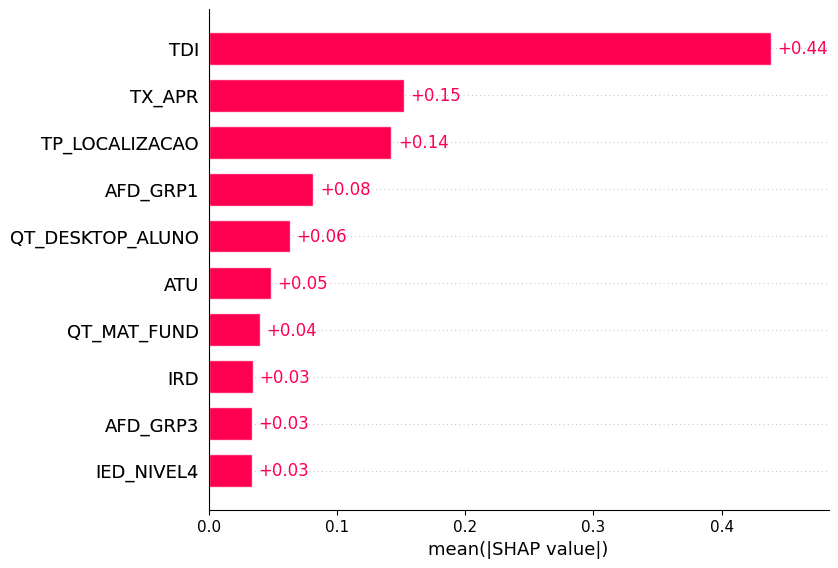

In [16]:
shap.plots.bar(shap_values)

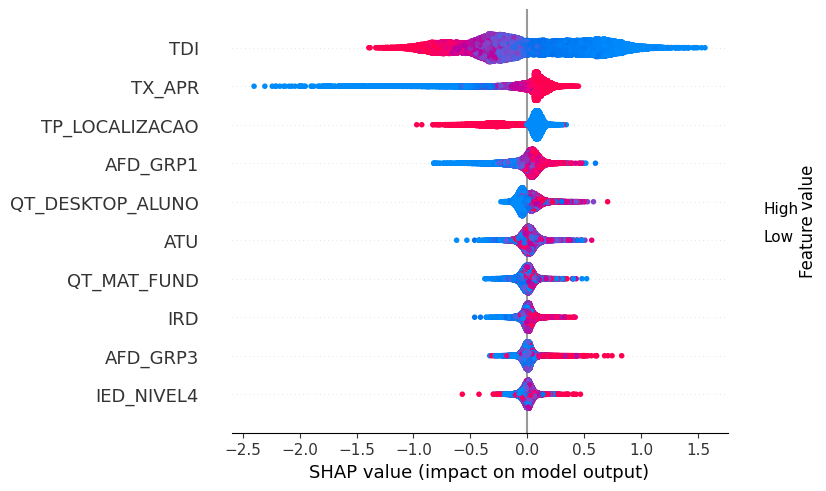

In [22]:
shap.plots.beeswarm(shap_values)

Look at individual predictions

In [24]:
idx = 0
df_rf_test.iloc[:, idx].values

array([100. ,  94.2, 100. , ...,  97.1,  96.6,  97.8])

In [26]:
# visualize the first prediction's explanation with a force plot
shap.initjs()
shap.plots.force(shap_values[idx])

In [27]:
first_row_shap = shap_values[0]
shapley_values = first_row_shap.values

print(f'Predicted Value: {first_row_shap.base_values + sum(shapley_values)}\n')
print(f'Baseline: {first_row_shap.base_values}\n')

print('Shapley values for features:')
for i, shapley_value in enumerate(shapley_values):
    print(f'{shap_values.feature_names[i]}: {shapley_value}')

print('\nMost to least influential features:')
most_influential_ordering = np.argsort(-np.abs(shapley_values))
for i in range(len(shapley_values)):
    print(f'{shap_values.feature_names[most_influential_ordering[i]]}: {shapley_values[most_influential_ordering[i]]}')

Predicted Value: [5.06]

Baseline: [5.26547368]

Shapley values for features:
TX_APR: 0.24967810635052334
TDI: -0.5364898582188738
IRD: 0.01580390164015567
IED_NIVEL4: 0.03972616932891229
ATU: 0.04939327248388116
AFD_GRP1: 0.05252660668120948
AFD_GRP3: 0.040863607104774914
TP_LOCALIZACAO: -0.18262138896300176
QT_MAT_FUND: 0.00012170019509107314
QT_DESKTOP_ALUNO: 0.06552420767187214

Most to least influential features:
TDI: -0.5364898582188738
TX_APR: 0.24967810635052334
TP_LOCALIZACAO: -0.18262138896300176
QT_DESKTOP_ALUNO: 0.06552420767187214
AFD_GRP1: 0.05252660668120948
ATU: 0.04939327248388116
AFD_GRP3: 0.040863607104774914
IED_NIVEL4: 0.03972616932891229
IRD: 0.01580390164015567
QT_MAT_FUND: 0.00012170019509107314


In [29]:
text_example = df_rf_test.iloc[:, 0].values
for i, feature in enumerate(cal_features):
    print(f'{feature}: \t {text_example[i]}')

TX_APR: 	 100.0
TDI: 	 94.2
IRD: 	 100.0
IED_NIVEL4: 	 100.0
ATU: 	 83.5
AFD_GRP1: 	 100.0
AFD_GRP3: 	 99.1
TP_LOCALIZACAO: 	 100.0
QT_MAT_FUND: 	 96.6
QT_DESKTOP_ALUNO: 	 100.0


### Train a model in Tensorflow

In [ ]:
# for the shap library to work properly
#tf.compat.v1.disable_v2_behavior()

In [38]:
# Build and train model
#tf.random.set_seed(42)
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation=tf.nn.relu, input_shape=[df_rf_train.shape[1]]),
        tf.keras.layers.Dense(128, activation=tf.nn.relu),
        tf.keras.layers.Dense(32, activation=tf.nn.relu),
        tf.keras.layers.Dense(8, activation=tf.nn.relu),
        tf.keras.layers.Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
                  loss='mse',
                  metrics=['mae', 'mse', 'mape'])
    return model

tf_model = build_model()

#early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
history = tf_model.fit(df_rf_train, alvo_train, epochs=200,
                       validation_data = (df_rf_test, alvo_test)
                       #validation_data = (X_val, y_val)
                      )

hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

Epoch 1/200
1357/1357 [==============================] - 1s 717us/step - loss: 17.5771 - mae: 1.7012 - mse: 17.5771 - mape: 32.9300 - val_loss: 1.7460 - val_mae: 1.0786 - val_mse: 1.7460 - val_mape: 22.1404
Epoch 2/200
1357/1357 [==============================] - 1s 559us/step - loss: 0.7873 - mae: 0.6868 - mse: 0.7873 - mape: 13.4888 - val_loss: 0.8420 - val_mae: 0.7441 - val_mse: 0.8420 - val_mape: 15.3722
Epoch 3/200
1357/1357 [==============================] - 1s 551us/step - loss: 0.7632 - mae: 0.6714 - mse: 0.7632 - mape: 13.1678 - val_loss: 0.5473 - val_mae: 0.5677 - val_mse: 0.5473 - val_mape: 11.0435
Epoch 4/200
1357/1357 [==============================] - 1s 554us/step - loss: 0.6934 - mae: 0.6447 - mse: 0.6934 - mape: 12.6756 - val_loss: 0.5156 - val_mae: 0.5492 - val_mse: 0.5156 - val_mape: 10.8987
Epoch 5/200
1357/1357 [==============================] - 1s 567us/step - loss: 0.6552 - mae: 0.6249 - mse: 0.6552 - mape: 12.3036 - val_loss: 0.5448 - val_mae: 0.5665 - val_mse: 

Epoch 41/200
1357/1357 [==============================] - 1s 622us/step - loss: 0.4841 - mae: 0.5326 - mse: 0.4841 - mape: 10.4709 - val_loss: 0.4763 - val_mae: 0.5287 - val_mse: 0.4763 - val_mape: 10.3903
Epoch 42/200
1357/1357 [==============================] - 1s 610us/step - loss: 0.4880 - mae: 0.5330 - mse: 0.4880 - mape: 10.4738 - val_loss: 0.4607 - val_mae: 0.5205 - val_mse: 0.4607 - val_mape: 10.4184
Epoch 43/200
1357/1357 [==============================] - 1s 610us/step - loss: 0.4809 - mae: 0.5304 - mse: 0.4809 - mape: 10.4616 - val_loss: 0.4580 - val_mae: 0.5188 - val_mse: 0.4580 - val_mape: 10.3514
Epoch 44/200
1357/1357 [==============================] - 1s 600us/step - loss: 0.4799 - mae: 0.5291 - mse: 0.4799 - mape: 10.4410 - val_loss: 0.4648 - val_mae: 0.5206 - val_mse: 0.4648 - val_mape: 10.2007
Epoch 45/200
1357/1357 [==============================] - 1s 560us/step - loss: 0.4773 - mae: 0.5293 - mse: 0.4773 - mape: 10.4321 - val_loss: 0.4613 - val_mae: 0.5195 - val_ms

Epoch 81/200
1357/1357 [==============================] - 1s 757us/step - loss: 0.4706 - mae: 0.5228 - mse: 0.4706 - mape: 10.2685 - val_loss: 0.4554 - val_mae: 0.5141 - val_mse: 0.4554 - val_mape: 10.0810
Epoch 82/200
1357/1357 [==============================] - 1s 733us/step - loss: 0.4688 - mae: 0.5219 - mse: 0.4688 - mape: 10.2627 - val_loss: 0.4691 - val_mae: 0.5236 - val_mse: 0.4691 - val_mape: 10.3668
Epoch 83/200
1357/1357 [==============================] - 1s 736us/step - loss: 0.4640 - mae: 0.5200 - mse: 0.4640 - mape: 10.2156 - val_loss: 0.4527 - val_mae: 0.5148 - val_mse: 0.4527 - val_mape: 10.2821
Epoch 84/200
1357/1357 [==============================] - 1s 761us/step - loss: 0.4619 - mae: 0.5182 - mse: 0.4619 - mape: 10.1756 - val_loss: 0.4549 - val_mae: 0.5165 - val_mse: 0.4549 - val_mape: 10.3399
Epoch 85/200
1357/1357 [==============================] - 1s 863us/step - loss: 0.4683 - mae: 0.5213 - mse: 0.4683 - mape: 10.2402 - val_loss: 0.4691 - val_mae: 0.5284 - val_ms

Epoch 121/200
1357/1357 [==============================] - 1s 549us/step - loss: 0.4661 - mae: 0.5188 - mse: 0.4661 - mape: 10.2150 - val_loss: 0.4514 - val_mae: 0.5131 - val_mse: 0.4514 - val_mape: 10.1736
Epoch 122/200
1357/1357 [==============================] - 1s 547us/step - loss: 0.4633 - mae: 0.5178 - mse: 0.4633 - mape: 10.1692 - val_loss: 0.4663 - val_mae: 0.5190 - val_mse: 0.4663 - val_mape: 10.1133
Epoch 123/200
1357/1357 [==============================] - 1s 549us/step - loss: 0.4619 - mae: 0.5185 - mse: 0.4619 - mape: 10.1786 - val_loss: 0.4654 - val_mae: 0.5209 - val_mse: 0.4654 - val_mape: 10.1672
Epoch 124/200
1357/1357 [==============================] - 1s 546us/step - loss: 0.4575 - mae: 0.5163 - mse: 0.4575 - mape: 10.1688 - val_loss: 0.4661 - val_mae: 0.5216 - val_mse: 0.4661 - val_mape: 10.1969
Epoch 125/200
1357/1357 [==============================] - 1s 549us/step - loss: 0.4601 - mae: 0.5162 - mse: 0.4601 - mape: 10.1441 - val_loss: 0.4668 - val_mae: 0.5256 - v

1357/1357 [==============================] - 1s 596us/step - loss: 0.4569 - mae: 0.5139 - mse: 0.4569 - mape: 10.0748 - val_loss: 0.4496 - val_mae: 0.5118 - val_mse: 0.4496 - val_mape: 10.1487
Epoch 161/200
1357/1357 [==============================] - 1s 590us/step - loss: 0.4641 - mae: 0.5166 - mse: 0.4641 - mape: 10.1200 - val_loss: 0.4678 - val_mae: 0.5213 - val_mse: 0.4678 - val_mape: 10.1223
Epoch 162/200
1357/1357 [==============================] - 1s 586us/step - loss: 0.4526 - mae: 0.5123 - mse: 0.4526 - mape: 10.1064 - val_loss: 0.4583 - val_mae: 0.5187 - val_mse: 0.4583 - val_mape: 10.3171
Epoch 163/200
1357/1357 [==============================] - 1s 591us/step - loss: 0.4507 - mae: 0.5100 - mse: 0.4507 - mape: 9.9824 - val_loss: 0.4662 - val_mae: 0.5197 - val_mse: 0.4662 - val_mape: 10.0687
Epoch 164/200
1357/1357 [==============================] - 1s 600us/step - loss: 0.4516 - mae: 0.5126 - mse: 0.4516 - mape: 10.0901 - val_loss: 0.4659 - val_mae: 0.5253 - val_mse: 0.4659 

Epoch 200/200
1357/1357 [==============================] - 1s 567us/step - loss: 0.4490 - mae: 0.5097 - mse: 0.4490 - mape: 9.9929 - val_loss: 0.4658 - val_mae: 0.5198 - val_mse: 0.4658 - val_mape: 10.1484


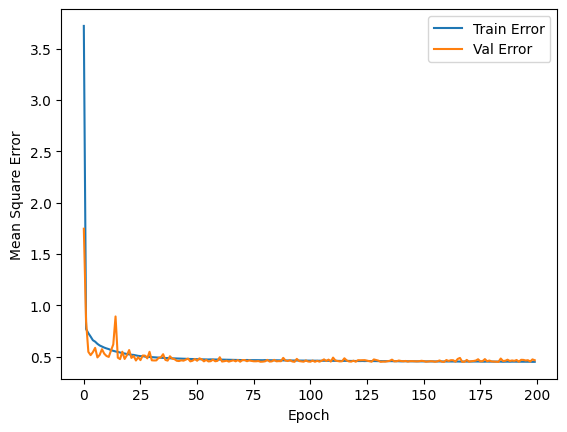

In [39]:
def plot_history(history):
    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error')
    plt.plot(history['epoch'], history['mse'], label='Train Error')
    plt.plot(history['epoch'], history['val_mse'], label = 'Val Error')
    plt.legend()

plot_history(hist)